# 번역기 프로젝트
한국어 챗봇 만들고 BLEU Score로 평가해보는 프로젝트

# 영어-스페인어 데이터 사용해서 실습

In [ ]:
!mkdir -p ~/work/transformer_chatbot/data/spa-eng

In [ ]:
!python3 -m pip install --upgrade pip
!python3 -m pip install konlpy # Python 3.x
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) # MeCab 설치하기

In [ ]:
!pip install sentencepiece nltk

In [ ]:
import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

In [ ]:
import urllib.request
import zipfile

zip_filename = "spa-eng.zip"
zip_url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"

urllib.request.urlretrieve(zip_url, zip_filename)

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(os.path.dirname(zip_filename))

다운로드한 데이터 확인해보기

In [ ]:
extracted_folder = "./spa-eng"
file_path = os.path.join(extracted_folder, "spa.txt")

with open(file_path, "r") as f:
    spa_eng_sentences = f.read().splitlines()

spa_eng_sentences = list(set(spa_eng_sentences))
total_sentence_count = len(spa_eng_sentences)
print("Example:", total_sentence_count)

for sen in spa_eng_sentences[0:100][::20]:
    print(">>", sen)

In [ ]:
# 전처리 함수
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    return sentence
# 모든 데이터에 같은 전처리
spa_eng_sentences = list(map(preprocess_sentence, spa_eng_sentences))

테스트 데이터 분리하기 전체 중 0.5정도 테스트로 사용하기

In [ ]:
test_sentence_count = total_sentence_count // 200
print("Test Size: ", test_sentence_count)
print("\n")

train_spa_eng_sentences = spa_eng_sentences[:-test_sentence_count]
test_spa_eng_sentences = spa_eng_sentences[-test_sentence_count:]

print("Train Example:", len(train_spa_eng_sentences))
for sen in train_spa_eng_sentences[0:100][::20]:
    print(">>", sen)
print("\n")
print("Test Example:", len(test_spa_eng_sentences))
for sen in test_spa_eng_sentences[0:100][::20]:
    print(">>", sen)

영어와 스페인어를 split('\t')으로 분리하기 \
tab 이전이 영어, 이후가 스페인어 문장

In [ ]:
def split_spa_eng_sentences(spa_eng_sentences):
    spa_sentences = []
    eng_sentences = []
    for spa_eng_sentence in tqdm(spa_eng_sentences):
        eng_sentence, spa_sentence = spa_eng_sentence.split('\t')
        spa_sentences.append(spa_sentence)
        eng_sentences.append(eng_sentence)
    return eng_sentences, spa_sentences

In [ ]:
# 전체 데이터를 영어랑 스페인어로 쪼개기
train_eng_sentences, train_spa_sentences = split_spa_eng_sentences(train_spa_eng_sentences)
print(len(train_eng_sentences))
print(train_eng_sentences[0])
print('\n')
print(len(train_spa_sentences))
print(train_spa_sentences[0])

In [ ]:
test_eng_sentences, test_spa_sentences = split_spa_eng_sentences(test_spa_eng_sentences)
print(len(test_eng_sentences))
print(test_eng_sentences[0])
print('\n')
print(len(test_spa_sentences))
print(test_spa_sentences[0])

### 토큰화

In [ ]:
def generate_tokenizer(corpus,
                       vocab_size,
                       lang="spa-eng",
                       pad_id=0,   # pad token의 일련번호
                       bos_id=1,  # 문장의 시작을 의미하는 bos token(<s>)의 일련번호
                       eos_id=2,  # 문장의 끝을 의미하는 eos token(</s>)의 일련번호
                       unk_id=3):   # unk token의 일련번호
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
        for row in corpus: f.write(str(row) + '\n')

    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
        '--input=./%s --model_prefix=%s --vocab_size=%d'\
        % (file, model, vocab_size) + \
        '--pad_id=%d --bos_id=%d --eos_id=%d --unk_id=%d'\
        % (pad_id, bos_id, eos_id, unk_id)
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)

    return tokenizer


영어사전 스페인사전 두 개 하나로 합치기

In [ ]:
VOCAB_SIZE = 20000
tokenizer = generate_tokenizer(train_eng_sentences + train_spa_sentences, VOCAB_SIZE, 'spa-eng')
tokenizer.set_encode_extra_options("bos:eos")  # 문장 양 끝에 <s> , </s> 추가

In [ ]:
tokenizer.get_piece_size()

In [ ]:
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        # 단어를 숫자로 바꾸기
        tokens = tokenizer.encode_as_ids(sentence)
        # 숫자 리스트 담고
        corpus.append(tokens)
    return corpus
# 영어랑 스페인어 문장 숫자 뭉치로 바꾸기
eng_corpus = make_corpus(train_eng_sentences, tokenizer)
spa_corpus = make_corpus(train_spa_sentences, tokenizer)

토큰화 확인

In [ ]:
print(train_eng_sentences[5])
print(eng_corpus[5])
print('\n')
print(train_spa_sentences[1])
print(spa_corpus[1])

패딩 넣기\
한 문장의 토큰 길이가 50이 되도록 설정

In [ ]:
MAX_LEN = 50

def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        # 초과 길이는 자르고
        if len(seq) > max_len:
            seq = seq[:max_len]
        # 부족한 길이는 pad_value로 채우기
        else:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)
# 영어, 스페인 뭉치 50글자게 맞춰서 바꾸기
enc_ndarray = pad_sequences_custom(eng_corpus, max_len=MAX_LEN, pad_value=0)
dec_ndarray = pad_sequences_custom(spa_corpus, max_len=MAX_LEN, pad_value=0)

print(enc_ndarray.shape)  # 예) [batch_size, 50]
print(dec_ndarray.shape)  # 예) [batch_size, 50]

이제 모델 훈련에 사용될 수 있도록 영어와 스페인어 데이터를 묶어 배치 크기의 텐서로 만들어 줍니다. 데이터 셋이 완성 되었어요!

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 영어 스페인어 데이터셋 한쌍으로
train_dataset = TensorDataset(enc_ndarray, dec_ndarray)
# 셔플로 섞기
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

## 트랜스포머 구현하기

#### Positional Encoding

In [ ]:

def positional_encoding(pos, d_model):
    # 각 위치마다 어떤 각도를 가질지 계산
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))
    # 단어 안에 있는 숫자에 각도 채우기
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
    # 전체 문장 길이만큼의 각도표 만들기
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    # 짝수는 사인, 홀수는 코사인으로
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

#### 마스크 생성

In [ ]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask


위 내용 확인해보기

In [ ]:
sample_seq = torch.tensor([[7, 8, 0, 0]]) # 4글자 문장인데 뒤에 2개가 빈칸!
# 마스크 생성
sample_mask = generate_padding_mask(sample_seq)
print("원본 문장 숫자:", sample_seq)
print("마스크 결과:\n", sample_mask)
# 출력 결과에서 1.0이라고 표시된 곳이 패딩

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 10글자짜리 룩어헤드 마스크 생성
size = 10
mask = torch.triu(torch.ones(size, size), diagonal=1)

# 시각화를 위해 넘파이(numpy) 배열로
mask_np = mask.cpu().numpy()

# 3. 그리기
plt.figure(figsize=(6, 6))
plt.imshow(mask_np, cmap='Blues')
plt.title("Look-ahead Mask (Blue is Hidden)")
plt.xlabel("Target Token Index")
plt.ylabel("Conditioning Token Index")
plt.colorbar()
plt.show()

In [ ]:
# 인코더 마스크를 만들고 모양을 찍어보기
enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_ndarray[:1], dec_ndarray[:1])

print("Encoder Mask Shape:", enc_mask.shape)

#### multi head attention

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model # 한 단어가 가진 전체 숫자 정보양

        # 전체 정보 d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        # Q질문이랑 K이름표 곱해서 관련성 점수 계산하기
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)
        # softmax써서 모든 점수 합이 1(100%)되게 관심도로 바꾸기
        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        # 계산한 관심도 v에 곱해서 최종결과
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention 서로 얼마나 관련 있는지 집중해서 보고
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights


멀티헤드 확인해보기

In [ ]:
# [문장 1개, 단어 4개, 단어당 숫자 12개]
# d_model=12, num_heads=4 헤드당  3개(12/4)담당
test_d_model = 12
test_num_heads = 4
mha = MultiHeadAttention(d_model=test_d_model, num_heads=test_num_heads)

# 테스트 문장 생성 (Batch_size=1, Seq_len=4, d_model=12)
test_input = torch.randn(1, 4, test_d_model)

# 실제로 어텐션 통과시켜보기
# Q, K, V를 모두 똑같은 문장 넣기
output, attn_weights = mha(test_input, test_input, test_input, mask=None)

# 결과 확인
print("1. 입력 모양 (Input Shape):", test_input.shape)
print("2. 출력 모양 (Output Shape):", output.shape)
print("3. 어텐션 가중치 모양 (Attn Weights Shape):", attn_weights.shape)
print("-" * 30)

# 관심도 점수(Attention Weight)가 잘 계산됐는지 헤드 한개만 꺼내보기
# [Batch 0, Head 0, 모든 단어, 모든 단어]
first_head_attn = attn_weights[0, 0, :, :].detach().numpy()
print("첫 번째 전문가의 관심도 점수 (단어들끼리 얼마나 친한가?):\n", first_head_attn)

# 점수의 합이 1이 되는지 확인 (Softmax가 잘 됐는지)
print("\n첫 번째 단어가 다른 단어들에 주는 관심도 합:", first_head_attn[0].sum())

In [ ]:
 # 3번, 4번 단어는 빈칸(Padding)이라고 가정한 마스크 만들기
test_mask = torch.tensor([[[[0, 0, 1, 1]]]]) # 1은 가려라

# 마스크를 넣어서 다시 계산
output_masked, attn_masked = mha(test_input, test_input, test_input, mask=test_mask)

# 가려진 부분의 점수 확인
masked_scores = attn_masked[0, 0, 0, :].detach().numpy()
print("마스크 적용 후 첫 번째 단어의 관심도:", masked_scores)

#### position wise feed forward network

In [ ]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff
        # 정보 늘려주기->다시 줄이고 -> relu로 0보다 작은 값은 다 날리기
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 단어를 넓게 펼쳐서 fc1 특징 뽑아내고 불필요한 정보는 ReLU로 거르기
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        # 거른 정보를 다시 원래 모양으로 정리하기
        out = self.fc2(out)          # 두 번째 Dense
        return out

In [ ]:
# 테스트 데이터: [1개 문장, 4개 단어, 12개 특징]
test_input = torch.randn(1, 4, 12)

# d_model=12, d_ff=48 (보통 4배)
ffn = PoswiseFeedForwardNet(d_model=12, d_ff=48)

output = ffn(test_input)

print("입력 모양:", test_input.shape)
print("출력 모양:", output.shape)

#### Encoder Layer

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

#### Decoder Layer

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        # Q는 out 내가 쓴글에서 k,v는 인코더 결과에서 가져옴
        # 지금 이렇게 썼는데 원본 문장에서는 어떤 단어가 제일 중요한지 묻는거
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn


#### Encoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers #레이어 몇개 쌓을지
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        # 모든 층을 통과하고 데이터를 다듬어서 다음 단계로 넘겨줌
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # ← Pre-LN 표준

    def forward(self, x, mask):
        out = x; enc_attns = [] # 어디를 봤는지 확인하려고 각 층 관심도 저장해둠
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            enc_attns.append(enc_attn)
        # 모든 층 다 통과하고 마지막으로 정규화 수행
        out = self.final_norm(out)  # ← stack 끝나고 정규화
        return out, enc_attns

#### Decoder

In [ ]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        # 디코더 모든 작업 끝나고 최종 데이터 정돈
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # ← Pre-LN 표준

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x; dec_attns = []; dec_enc_attns = []
        for layer in self.dec_layers:
            out, dec_attn, dec_enc_attn = layer(out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        out = self.final_norm(out)  # ← stack 끝나고 정규화
        return out, dec_attns, dec_enc_attns

#### Transformer 전체 모델 조립

In [ ]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1) #문장에 단어가 몇개 있는 확인
        out = emb(x)  # [batch_size, seq_len, d_model] 단어 숫자로 변환
        # 숫자가 너무 작아지지 않게 sqrt 곱해줌
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out) # 어떤 단어가 올 확률 제일 높은지 점수 매기기
        return logits, enc_attns, dec_attns, dec_enc_attns


#### 모델 인스턴스 생성

In [ ]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(device)

d_model = 512

In [ ]:
# 모델의 총 파라미터(숫자) 개수 확인하기
total_params = sum(p.numel() for p in transformer.parameters())
print(f"총 지식량(파라미터): {total_params:,}개")

#### learning rate

In [ ]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=60):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5 #시간이 지날수록 학습 속도 줄이는 부분
        arg2 = step * (self.warmup_steps ** -1.5) # 초반 학습 속도 서서히 올리는 부분
        return (self.d_model ** -0.5) * min(arg1, arg2) # 두 값 중 작은 것 선택해 처음은 상승, 나중에 하강 그래프

# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model)



#### optimizer / loss fuction

In [ ]:

optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_leㅎn, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

In [ ]:
import matplotlib.pyplot as plt

lr_test = LearningRateScheduler(512, warmup_steps=4000)
steps = range(1, 20000)
lrs = [lr_test(s) for s in steps]

plt.plot(steps, lrs)
plt.title("Learning Rate Schedule")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.show()

#### Train step

In [ ]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold, predictions)

    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

In [ ]:
%%time

EPOCHS = 3

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)  # train_loader는 PyTorch DataLoader입니다.
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        # train_step 함수는 (loss, enc_attns, dec_attns, dec_enc_attns)를 반환합니다.
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)

        total_loss += loss.item()  # PyTorch에서는 loss.numpy() 대신 loss.item() 사용
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    print(f"Epoch {epoch+1}, Loss: {total_loss / dataset_count:.4f}")

# BLEU Score
번역 성능 측정하기

In [ ]:
# 아래 두 문장을 바꿔가며 테스트 해보세요
reference = "많 은 자연어 처리 연구자 들 이 트랜스포머 를 선호 한다".split()
candidate = "적 은 자연어 학 개발자 들 가 트랜스포머 을 선호 한다 요".split()

print("원문:", reference)
print("번역문:", candidate)
print("BLEU Score:", sentence_bleu([reference], candidate))

In [ ]:
print("1-gram:", sentence_bleu([reference], candidate, weights=[1, 0, 0, 0]))
print("2-gram:", sentence_bleu([reference], candidate, weights=[0, 1, 0, 0]))
print("3-gram:", sentence_bleu([reference], candidate, weights=[0, 0, 1, 0]))
print("4-gram:", sentence_bleu([reference], candidate, weights=[0, 0, 0, 1]))

#### SmoothingFunction()으로 BLEU Score 보정하기

In [ ]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)  # smoothing_function 적용

print("BLEU-1:", calculate_bleu(reference, candidate, weights=[1, 0, 0, 0])) #단어 하나하낙 얼마나 일치하는지?
print("BLEU-2:", calculate_bleu(reference, candidate, weights=[0, 1, 0, 0])) #두 단어씩 짝지었을때 얼마나 일치하는지?
print("BLEU-3:", calculate_bleu(reference, candidate, weights=[0, 0, 1, 0]))
print("BLEU-4:", calculate_bleu(reference, candidate, weights=[0, 0, 0, 1]))

print("\nBLEU-Total:", calculate_bleu(reference, candidate))

모델의 BLEU Score를 측정하는 함수 구현

In [ ]:
import torch
import torch.nn.functional as F

def translate(tokens, model, src_tokenizer, tgt_tokenizer):
    # tokens: 입력 토큰 리스트
    # MAX_LEN: 최대 길이 (전역 변수 혹은 상수)
    # device: 모델과 데이터가 위치한 디바이스
    if isinstance(tokens, str):
        tokens = src_tokenizer.encode_as_ids(tokens)

    # tokens 길이가 MAX_LEN보다 크면 자르고, 작으면 0으로 패딩
    if len(tokens) > MAX_LEN:
        tokens = tokens[:MAX_LEN]
    else:
        tokens = tokens + [0] * (MAX_LEN - len(tokens))

    # 배치 차원을 추가하여 텐서로 변환 (shape: [1, MAX_LEN])
    padded_tokens = torch.tensor([tokens], dtype=torch.long, device=device)

    ids = []
    # 디코더의 첫 입력은 BOS 토큰 (배치 차원 추가)
    output = torch.tensor([[tgt_tokenizer.bos_id()]], dtype=torch.long, device=device)

    for i in range(MAX_LEN):
        # generate_masks는 padded_tokens와 현재 output으로부터 마스크들을 생성합니다.
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(padded_tokens, output)

        # 모델 예측: predictions shape: [batch, seq_len, num_classes]
        predictions, _, _, _ = model(padded_tokens, output, enc_padding_mask, combined_mask, dec_padding_mask)

        # 마지막 시퀀스 위치의 예측값을 소프트맥스 후 argmax로 선택
        predicted_id = predictions[0, -1].softmax(dim=-1).argmax(dim=-1).item()

        # EOS 토큰에 도달하면 현재까지의 예측 토큰 ids를 디코딩 후 반환
        if tgt_tokenizer.eos_id() == predicted_id:
            result = tgt_tokenizer.decode_ids(ids)
            return result

        ids.append(predicted_id)
        # 현재 output에 새로운 예측 토큰을 연결 (dim=1)
        new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
        output = torch.cat([output, new_token], dim=1)

    result = tgt_tokenizer.decode_ids(ids)
    return result

In [ ]:
def eval_bleu_single(model, src_sentence, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    src_tokens = src_tokenizer.encode_as_ids(src_sentence)
    tgt_tokens = tgt_tokenizer.encode_as_ids(tgt_sentence)

    if (len(src_tokens) > MAX_LEN): return None
    if (len(tgt_tokens) > MAX_LEN): return None

    reference = tgt_sentence.split() #실제 정답을 단어 단위로 쪼개기
    candidate = translate(src_tokens, model, src_tokenizer, tgt_tokenizer).split() # 모델이 번역한 결과를 단어 단위로 쪼개기

    score = sentence_bleu([reference], candidate,
                          smoothing_function=SmoothingFunction().method1) # 채점하고 스무딩펑션으로 단어 하나 틀렸다고 0점 되는거 막기

    if verbose:
        print("Source Sentence: ", src_sentence) #입력한 영어문장
        print("Model Prediction: ", candidate) # 스페인어 번역 결과
        print("Real: ", reference) # 실제 스페인어 정답
        print("Score: %lf\n" % score) #BLEU 점수

    return score

In [ ]:
test_idx = 0

eval_bleu_single(transformer,
                 test_eng_sentences[test_idx],
                 test_spa_sentences[test_idx],
                 tokenizer,
                 tokenizer)

학습이 부족한지  0.5점 정도로 번역을 실패함

eval_bleu 함수

In [ ]:
def eval_bleu(model, src_sentences, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    total_score = 0.0
    sample_size = len(src_sentences) #테스트할 문장 개수

    for idx in tqdm(range(sample_size)):
        # 아까 만든 single 반복해서 점수 확인
        score = eval_bleu_single(model, src_sentences[idx], tgt_sentence[idx], src_tokenizer, tgt_tokenizer, verbose)
        # 문장 너무 길어서 채점안했으면 점수에 더하지 않기
        if not score: continue

        total_score += score

    print("Num of Sample:", sample_size) #총 몇 문제 풀었는지?
    print("Total Score:", total_score / sample_size) # 평균 점수 몇점인지?

In [ ]:
eval_bleu(transformer, test_eng_sentences, test_spa_sentences, tokenizer, tokenizer, verbose=False)

# Beam Search Decoder

In [ ]:
def beam_search_decoder(prob, beam_size):
    sequences = [[[], 1.0]]  # 생성된 문장과 점수를 저장
    # 문장의 각 위치 마다 반복
    for tok in prob:
        all_candidates = []
        # 현재 유지하는 시퀀스를 하나씩 꺼냄
        for seq, score in sequences:
            for idx, p in enumerate(tok): # 각 단어의 확률을 총점에 누적 곱
                candidate = [seq + [idx], score * -math.log(-(p-1))]
                all_candidates.append(candidate)
        # 모든 후보 중 점수 가장 높은 순서대로 줄세우기
        ordered = sorted(all_candidates,
                         key=lambda tup:tup[1],
                         reverse=True) # 총점 순 정렬
        sequences = ordered[:beam_size] # Beam Size에 해당하는 문장만 저장

    return sequences

In [ ]:
vocab = {
    0: "<pad>",
    1: "까요?",
    2: "커피",
    3: "마셔",
    4: "가져",
    5: "될",
    6: "를",
    7: "한",
    8: "잔",
    9: "도",
}

prob_seq = [[0.01, 0.01, 0.60, 0.32, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.75, 0.01, 0.01, 0.17],
            [0.01, 0.01, 0.01, 0.35, 0.48, 0.10, 0.01, 0.01, 0.01, 0.01],
            [0.24, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.68],
            [0.01, 0.01, 0.12, 0.01, 0.01, 0.80, 0.01, 0.01, 0.01, 0.01],
            [0.01, 0.81, 0.01, 0.01, 0.01, 0.01, 0.11, 0.01, 0.01, 0.01],
            [0.70, 0.22, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
            [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]]

prob_seq = np.array(prob_seq)
beam_size = 6

result = beam_search_decoder(prob_seq, beam_size)

for seq, score in result:
    sentence = ""

    for word in seq:
        sentence += vocab[word] + " "

    print(sentence, "// Score: %.4f" % score)

Beam search Decoder 평가하기

In [ ]:
import torch
import torch.nn.functional as F

def calc_prob(src_ids, tgt_ids, model):
    # 마스크 생성 (PyTorch 버전)
    enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(src_ids, tgt_ids)

    # 모델 forward pass
    # 모델에 데이터 넣고 예측값 없기. 여기에서는 raw logits 점수 형태로 나옴
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src_ids,
        tgt_ids,
        enc_padding_mask,
        combined_mask,
        dec_padding_mask
    )

    # 마지막 차원에 대해 softmax 적용하여 확률값 계산
    return F.softmax(predictions, dim=-1)

In [ ]:
import numpy as np
import torch

def beam_search_decoder(sentence,
                        src_len,
                        tgt_len,
                        model,
                        src_tokenizer,
                        tgt_tokenizer,
                        beam_size):
    # 입력 문장을 토큰화
    tokens = src_tokenizer.encode_as_ids(sentence)

    # src_in: [1, src_len] 크기의 텐서로 padding (0: 패딩 토큰)
    padded = np.zeros((1, src_len), dtype=np.int64)
    padded[0, :len(tokens)] = tokens
    src_in = torch.tensor(padded, dtype=torch.long, device=device)

    # beam search용 캐시 배열들
    pred_cache = np.zeros((beam_size * beam_size, tgt_len), dtype=np.int64)
    pred_tmp = np.zeros((beam_size, tgt_len), dtype=np.int64)

    eos_flag = np.zeros((beam_size,), dtype=np.int64)  # EOS를 만난 branch 표시 (EOS: -1)
    scores = np.ones((beam_size,), dtype=np.float32)     # 각 branch의 score (확률 곱)

    # 디코더 첫 입력은 BOS 토큰
    pred_tmp[:, 0] = tgt_tokenizer.bos_id()

    # 초기 디코더 입력 (branch 0의 첫 토큰) -> shape: [1, 1]
    dec_in = torch.tensor(pred_tmp[0, :1], dtype=torch.long, device=device).unsqueeze(0)
    # calc_prob()는 softmax를 적용한 확률 텐서를 반환함
    prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()

    # seq_pos: 디코더 시퀀스 위치
    for seq_pos in range(1, tgt_len):
        score_cache = np.ones((beam_size * beam_size,), dtype=np.float32)

        # 각 beam branch에 대해 캐시 초기화
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            score_cache[cache_pos:cache_pos+beam_size] = scores[branch_idx]
            pred_cache[cache_pos:cache_pos+beam_size, :seq_pos] = pred_tmp[branch_idx, :seq_pos]

        # 각 beam branch에 대해 후보 확률 계산 및 캐시 업데이트
        for branch_idx in range(beam_size):
            cache_pos = branch_idx * beam_size
            if seq_pos != 1:
                # 해당 branch의 현재까지의 시퀀스를 디코더 입력으로 변환
                dec_in_np = pred_cache[branch_idx, :seq_pos]
                dec_in = torch.tensor(dec_in_np, dtype=torch.long, device=device).unsqueeze(0)
                prob = calc_prob(src_in, dec_in, model)[0, -1].detach().cpu().numpy()





            # 각 branch 내에서 beam_size만큼의 후보 토큰을 선택
            for beam_idx in range(beam_size):
                max_idx = np.argmax(prob)
                # 후보 branch의 score 업데이트 (곱셈으로 누적)
                score_cache[cache_pos + beam_idx] *= prob[max_idx]
                pred_cache[cache_pos + beam_idx, seq_pos] = max_idx
                # 이미 선택된 토큰은 다시 선택되지 않도록 -1로 마킹
                prob[max_idx] = -1

        # 각 beam branch에서 최고 score를 가진 후보를 선택
        for beam_idx in range(beam_size):
            if eos_flag[beam_idx] == -1: # 이미 끝난 문장은 건너뛰기
                continue
            max_idx = np.argmax(score_cache)
            prediction = pred_cache[max_idx, :seq_pos+1].copy()
            pred_tmp[beam_idx, :seq_pos+1] = prediction
            scores[beam_idx] = score_cache[max_idx]
            score_cache[max_idx] = -1  # 해당 후보 제거

            # 만약 EOS 토큰이면 해당 branch는 종료 표시 (-1)
            if prediction[-1] == tgt_tokenizer.eos_id():
                eos_flag[beam_idx] = -1

    # 각 branch의 예측 시퀀스에서 EOS 토큰 이전까지만 추출하여 결과 반환
    pred = []
    for long_pred in pred_tmp:
        eos_token = tgt_tokenizer.eos_id()
        # EOS 토큰이 없는 경우, 전체 시퀀스를 사용하도록 처리할 수 있음
        try:
            eos_idx = list(long_pred).index(eos_token)
        except ValueError:
            eos_idx = tgt_len - 1
        short_pred = long_pred[:eos_idx+1]
        pred.append(short_pred.tolist())

    return pred

In [ ]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                            candidate,
                            weights=weights,
                            smoothing_function=SmoothingFunction().method1)


In [ ]:
# 예시 사용법
ref = "I am a student".split()
cand = "I am a teacher".split()

score = calculate_bleu(ref, cand)
print(f"최종 점수: {score:.4f}")

In [ ]:
def beam_bleu(reference, ids, tokenizer):
    # 기준 문장을 토큰화
    reference_tokens = reference.split()

    total_score = 0.0
    num_candidates = len(ids) # 빔서치로 생성된 후보 문장 개수
    if num_candidates == 0:
        return 0.0

    for candidate_ids in ids:
        # 후보 문장을 디코딩 후 토큰화
        candidate_sentence = tokenizer.decode_ids(candidate_ids)
        candidate_tokens = candidate_sentence.split()

        score = calculate_bleu(reference_tokens, candidate_tokens)
        # 각 어떤 묹아이고 점수 몇 점인지 출력
        print(f"Reference: {reference_tokens}")
        print(f"Candidate: {candidate_tokens}")
        print(f"BLEU: {score}")

        total_score += score

    return total_score / num_candidates


In [ ]:
test_idx = 1

ids = \
beam_search_decoder(test_eng_sentences[test_idx],
                    MAX_LEN,
                    MAX_LEN,
                    transformer,
                    tokenizer,
                    tokenizer,
                    beam_size=5)

bleu = beam_bleu(test_spa_sentences[test_idx], ids, tokenizer)
print(bleu)

# data augmentation

In [ ]:
# 주피터 노트북 셀에서 바로 설치하기
!pip install gensim

In [ ]:
import gensim.downloader as api

wv = api.load('glove-wiki-gigaword-300')

In [ ]:
wv.most_similar("banana")

In [ ]:
sample_sentence = "you know ? all you need is attention ."
sample_tokens = sample_sentence.split()

selected_tok = random.choice(sample_tokens)

result = ""
for tok in sample_tokens:
    # 선택한 단어랑 현재 단어 일치하는지 확인
    if tok is selected_tok:
        # wv에서 가장 유사한 단[0][0]어 찾아서 교체하기
        result += wv.most_similar(tok)[0][0] + " "

    else:
        result += tok + " "

print("From:", sample_sentence)
print("To:", result)

#### Lexical substitution 구현

In [ ]:
def lexical_sub(sentence, wv):
    # 문장을 토큰화
    tokens = sentence.split()

    # 유효한 단어 필터링 (임베딩에 존재하는 단어만 고려)
    valid_tokens = [tok for tok in tokens if tok in wv]

    # 대체할 단어 선택 (임베딩 내 존재하는 단어 중 하나)
    if not valid_tokens:
        return sentence  # 모든 단어가 임베딩 내에 없으면 원래 문장 반환

    selected_tok = random.choice(valid_tokens)

    # 가장 유사한 단어 찾기
    similar_word = wv.most_similar(selected_tok)[0][0]

    # 변환된 문장 생성
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])

    return new_sentence

In [ ]:
new_corpus = []

for old_src in tqdm(test_eng_sentences):
    new_src = lexical_sub(old_src, wv)
    if new_src is not None:
        new_corpus.append(new_src)
    # Augmentation이 없더라도 원본 문장을 포함시킵니다
    new_corpus.append(old_src)

print(new_corpus[:10])

In [ ]:
# 데이터 개수 강제로 1:1 매칭
# 영어(src)의 개수를 기준으로 스페인어(tgt)를 똑같이 자르기
augmented_src = new_corpus
# train_spa_sentences를 2배 불리기 전에, 먼저 영어 개수만큼만 가져오기
augmented_tgt = train_spa_sentences[:len(augmented_src)]

print(f"영어 데이터 개수: {len(augmented_src)}")
print(f"스페인어 데이터 개수: {len(augmented_tgt)}")

# 다시 토큰화 및 패딩
src_tokens = [tokenizer.encode_as_ids(s) for s in augmented_src]
tgt_tokens = [tokenizer.encode_as_ids(s) for s in augmented_tgt]

src_padded = pad_sequences_custom(src_tokens, max_len=MAX_LEN)
tgt_padded = pad_sequences_custom(tgt_tokens, max_len=MAX_LEN)

# 넘파이 변환 및 텐서 생성
src_np = np.array(src_padded, dtype=np.int64)
tgt_np = np.array(tgt_padded, dtype=np.int64)

print(f"Source Shape: {src_np.shape}")
print(f"Target Shape: {tgt_np.shape}")

new_dataset = TensorDataset(
    torch.from_numpy(src_np),
    torch.from_numpy(tgt_np)
)

In [ ]:
test_idx = 0

# 빔 서치 디코더로 번역 결과 확인
ids = beam_search_decoder(
    augmented_src[test_idx], # 증강된 문장 중 하나
    MAX_LEN,
    MAX_LEN,
    transformer,
    tokenizer,
    tokenizer,
    beam_size=5
)

# 번역된 문장과 정답 비교 출력
print(f"영어 원문: {augmented_src[test_idx]}")
print(f"스페인어 정답: {augmented_tgt[test_idx]}")
print("-" * 30)

# 빔 서치 결과물들 출력
for i, candidate_ids in enumerate(ids):
    res = tokenizer.decode_ids(candidate_ids)
    print(f"후보 {i+1}: {res}")

In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):
    total_loss = 0.0

    tqdm_bar = tqdm(total=len(new_train_dataloader), desc=f"Epoch {epoch+1}")

    for batch, (src, tgt) in enumerate(new_train_dataloader):
        loss, _, _, _ = train_step(src, tgt, transformer, optimizer)

        total_loss += loss.item()
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    print(f"Epoch {epoch+1} Average Loss: {total_loss / len(new_train_dataloader):.4f}")

증간된 데이터 bleu 점수 확인

In [ ]:
eval_bleu(transformer, test_eng_sentences, test_spa_sentences, tokenizer, tokenizer, verbose=False)

In [ ]:
test_sentence = "I have a book."

# 변환된 숫자 리스트를 translate 함수에 넣rl
result = translate(test_tokens, transformer, tokenizer, tokenizer)

print(f"입력: {test_sentence}")
print(f"번역 결과: {result}")

In [ ]:
test_sentence = "I am studying"
result = translate(test_tokens, transformer, tokenizer, tokenizer)

print(f"입력: {test_sentence}")
print(f"번역 결과: {result}")

In [ ]:
test_sentence = "hi"
result = translate(test_tokens, transformer, tokenizer, tokenizer)

print(f"입력: {test_sentence}")
print(f"번역 결과: {result}")

In [ ]:
# 빔 서치를 통해 상위 5개의 번역 후보를 확인합니다.
ids = beam_search_decoder(test_sentence, MAX_LEN, MAX_LEN, transformer, tokenizer, tokenizer, beam_size=5)

for i, cand_ids in enumerate(ids):
    print(f"후보 {i+1}: {tokenizer.decode_ids(cand_ids)}")

# 한국어 챗봇 만들기

In [1]:
#GPU 확인
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-05-16 08:47:44.574741: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778921264.599808     487 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778921264.607883     487 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778921264.627777     487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778921264.627803     487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778921264.627806     487 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import os
output_dir = "/kaggle/working/transformer_chatbot/data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# ChatbotData.csv 다운로드
!wget https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv

--2026-05-16 08:47:56--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv.1’

ChatbotData.csv.1   100%[===================>] 868.99K  --.-KB/s    in 0.05s   

2026-05-16 08:47:56 (18.4 MB/s) - ‘ChatbotData.csv.1’ saved [889842/889842]



In [4]:
import os

!pip install -U gdown

file_id = "17ycFyBCtlQwRmTxyZR3IkBEITCyskI7v"
download_url = f"https://drive.google.com/uc?id={file_id}"

!gdown "{download_url}" -O /kaggle/working/ko.zip

ZIP_PATH = '/kaggle/working/ko.zip'

print("ZIP 파일이 있나요?", os.path.exists(ZIP_PATH))

Downloading...
From (original): https://drive.google.com/uc?id=17ycFyBCtlQwRmTxyZR3IkBEITCyskI7v
From (redirected): https://drive.google.com/uc?id=17ycFyBCtlQwRmTxyZR3IkBEITCyskI7v&confirm=t&uuid=e884769f-90d5-4b46-9c9f-6274f39a7fe3
To: /kaggle/working/ko.zip
100%|██████████████████████████████████████| 80.6M/80.6M [00:01<00:00, 70.7MB/s]
ZIP 파일이 있나요? True


In [5]:
import os

CSV_PATH = '/kaggle/working/ChatbotData.csv'

ZIP_PATH = '/kaggle/working/ko.zip' 

KO_TSV_PATH = '/kaggle/working/ko.tsv'

print("CSV 파일이 있나요?", os.path.exists(CSV_PATH))
print("ZIP 파일이 있나요?", os.path.exists(ZIP_PATH))

CSV 파일이 있나요? True
ZIP 파일이 있나요? True


In [6]:
!unzip -o /kaggle/working/ko.zip -d /kaggle/working/

Archive:  /kaggle/working/ko.zip
  inflating: /kaggle/working/ko.bin  
  inflating: /kaggle/working/ko.tsv  


In [7]:
!pip install konlpy

In [8]:
!pip install gensim -q

In [9]:
# Colab에서 MeCab 설치
!apt-get install -y mecab mecab-ipadic-utf8 libmecab-dev -q
!pip install mecab-python3 -q
!pip install unidic-lite -q

Reading package lists...
Building dependency tree...
Reading state information...
libmecab-dev is already the newest version (0.996-14build9).
mecab-ipadic-utf8 is already the newest version (2.7.0-20070801+main-3).
mecab is already the newest version (0.996-14build9).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.


In [10]:
# 대안: python-mecab-ko 패키지
!pip install python-mecab-ko -q

In [11]:
import numpy
import pandas
import torch
import nltk
import gensim

print(numpy.__version__)
print(pandas.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.0.2
2.3.3
2.10.0+cu128
3.9.1
4.4.0


lms에서 mecab으로 하다가 gpu가 안돼서 코랩으로 왔는데! mecab이 잘 안돼서 그냥 okt로 합니다.

In [12]:
from konlpy.tag import Okt
okt = Okt()

In [13]:
text = "안녕, 아이펠에서 공부하니 재밌니?"
print(okt.morphs(text))

['안녕', ',', '아이펠', '에서', '공부', '하니', '재밌니', '?']


#### 1. 데이터 다운로드

In [14]:
import pandas as pd
import urllib.request
data_path = "ChatbotData.csv"
url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"

df = pd.read_csv('ChatbotData.csv')

print(df.head())

questions = df['Q'].tolist()   # 질문 컬럼만 뽑아서 리스트로 저장
answers   = df['A'].tolist()   # 답변 컬럼만 뽑아서 리스트로 저장

print(f"질문 개수: {len(questions)}")  # 몇 개나 있는지 확인
print(f"답변 개수: {len(answers)}")

print(f"첫 번째 질문: {questions[0]}")
print(f"첫 번째 답변: {answers[0]}")

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
질문 개수: 11823
답변 개수: 11823
첫 번째 질문: 12시 땡!
첫 번째 답변: 하루가 또 가네요.


#### 2. 데이터 정제

In [15]:
# 전처리 함수
import re

def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^가-힣a-zA-Z0-9 ]", "", sentence)
    # strip(): 문장 앞뒤의 불필요한 공백 제거
    sentence = sentence.strip()
    return sentence

In [16]:
import re
# 질문과 답변 각각에 적용
questions = [preprocess_sentence(q) for q in questions]
answers   = [preprocess_sentence(a) for a in answers]

# 정제 후 빈 문장이 된 것들 제거
filtered = [(q, a) for q, a in zip(questions, answers) if len(q) > 0 and len(a) > 0]
questions, answers = zip(*filtered)

print(f"정제 후 데이터 수: {len(questions)}")
print(f"정제된 질문 예시: {questions[0]}")
print(f"정제된 답변 예시: {answers[0]}")

정제 후 데이터 수: 11823
정제된 질문 예시: 12시 땡
정제된 답변 예시: 하루가 또 가네요


#### 3.데이터 토큰화

In [17]:
def build_corpus(sources, targets, tokenize_fn, max_len=30):
    que_corpus = []
    ans_corpus = []
    seen_sources = set()
    seen_targets = set()

    # 중복 제외
    # 소스는 소스대로, 타겟은 타겟대로 따로 보기
    seen_sources = set()
    seen_targets = set()

    for src, tgt in zip(sources, targets):
        src = preprocess_sentence(src)
        tgt = preprocess_sentence(tgt)


        # 정제 후 빈 문장이면 건너뛰기
        if not src or not tgt:
            continue

        src_tokens = tokenize_fn(src)
        tgt_tokens = tokenize_fn(tgt)

        # 긴 문장은 제외
        if len(src_tokens) >= max_len or len(tgt_tokens) >= max_len:
            continue

        # 소스가 중복이거나 타겟이 중복이면 둘 다 건너뛰어요
        if src in seen_sources or tgt in seen_targets:
            continue

        # 중복 아니면 집합에 추가 (다음번 중복 체크용)
        seen_sources.add(src)
        seen_targets.add(tgt)

        que_corpus.append(src_tokens)
        ans_corpus.append(tgt_tokens)
    return que_corpus, ans_corpus

from konlpy.tag import Okt
okt = Okt()

que_corpus, ans_corpus = build_corpus(
    questions, answers, tokenize_fn=okt.morphs
)

print(f"corpus 크기: {len(que_corpus)}")
print(f"질문 토큰 예시: {que_corpus[0]}")
print(f"답변 토큰 예시: {ans_corpus[0]}")

corpus 크기: 7696
질문 토큰 예시: ['12시', '땡']
답변 토큰 예시: ['하루', '가', '또', '가네요']


#### 4. Augmentation

In [18]:
import zipfile
import os

# 압축 파일 경로
zip_path = '/kaggle/working/ko.zip'

# 압축 해제 (현재 작업 폴더에 풀기)
if not os.path.exists('/kaggle/working/ko.bin'):
    print("압축 해제 중")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/kaggle/working/') # 현재 폴더에 풀기
    print("압축 해제 완료")

print(os.listdir('/kaggle/working/'))  # ko.bin, ko.tsv 확인

['ko.bin', '.virtual_documents', 'ChatbotData.csv', 'transformer_chatbot', 'ko.tsv', 'ChatbotData.csv.1', 'best_chatbot.weights.h5', 'ko.zip']


ko.bin으로 하려니까 자꾸 에러가 나서 ko.tsv로 사용하기

In [19]:
# ko.tsv로 ko_model 만들기
import numpy as np
from gensim.models import KeyedVectors

print("ko_model 로딩 중")

words = []
vectors = []
standard_size = None

with open('/kaggle/working/ko.tsv', 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 3:
            continue
        word = parts[1]
        vec_str = parts[2].replace('[', '').replace(']', '').split()
        try:
            vec = [float(x) for x in vec_str]
            if standard_size is None:
                standard_size = len(vec)
            if len(vec) == standard_size:
                words.append(word)
                vectors.append(vec)
        except ValueError:
            continue

vectors_np = np.array(vectors, dtype=np.float32)
ko_model = KeyedVectors(vector_size=standard_size)
ko_model.add_vectors(words, vectors_np)

print(f"ko_model 완료 단어 수: {len(words)}개")

ko_model 로딩 중
ko_model 완료 단어 수: 18851개


In [20]:
try:
    # 사전에 들어있는 단어 목록 중 앞 10개 구경
    index_to_key = ko_model.index_to_key
    print(f"사전의 앞부분 단어들: {index_to_key[:10]}")

    # 실제로 존재하는 첫 번째 단어로 테스트
    test_word = index_to_key[0]
    result = ko_model.most_similar(test_word, topn=1)
    print(f"테스트 성공 '{test_word}'와 비슷한 단어 -> {result[0][0]}")

except Exception as e:
    print(f"에러: {e}")

사전의 앞부분 단어들: ['하', '이', '의', '는', '에', '를', '고', '가', '아', '로']
테스트 성공 '하'와 비슷한 단어 -> 결과


In [21]:
import random

def lexical_sub(tokens, model, prob=0.2, topn=1, threshold=0.7):
      # prob=0.2  → 각 단어마다 20% 확률로 교체
      # topn=1    → 가장 비슷한 단어 1개로 교체
      # threshold=0.7 → 유사도 70% 이상인 단어만 교체

    new_tokens = []
    for token in tokens:
        if random.random() < prob and token in model:
            similar = model.most_similar(token, topn=topn)
            if similar[0][1] >= threshold:
                new_tokens.append(similar[0][0])
            else:
                new_tokens.append(token)  # 유사도 낮으면 그대로
        else:
            new_tokens.append(token)
    return new_tokens

print("질문 증강 1번...")
aug_que_corpus  = [lexical_sub(q, ko_model) for q in que_corpus]

print("답변 증강...")
aug_ans_corpus  = [lexical_sub(a, ko_model) for a in ans_corpus]

# 4배를 위한 두 번째 질문 증강
# seed를 다르게 해서 첫 번째 증강과 다른 결과 나오게
random.seed(99)
print("질문 증강 2번...")
aug_que_corpus2 = [lexical_sub(q, ko_model) for q in que_corpus]

# 4배 증강
# 묶음1: 원본 질문    + 원본 답변
# 묶음2: 증강 질문1  + 원본 답변  (질문만 교체)
# 묶음3: 원본 질문   + 증강 답변  (답변만 교체)
# 묶음4: 증강 질문2  + 원본 답변  (다른 방식으로 질문 교체)
final_que = que_corpus + aug_que_corpus + que_corpus      + aug_que_corpus2
final_ans = ans_corpus + ans_corpus     + aug_ans_corpus  + ans_corpus

print(f"원본:    {len(que_corpus)}개")
print(f"증강 후: {len(final_que)}개")
print(f"배율:    {len(final_que) / len(que_corpus):.1f}배")

print(f"\n원본 질문:    {que_corpus[0]}")
print(f"증강 질문1:   {aug_que_corpus[0]}")
print(f"증강 질문2:   {aug_que_corpus2[0]}")
print(f"원본 답변:    {ans_corpus[0]}")
print(f"증강 답변:    {aug_ans_corpus[0]}")

질문 증강 1번...
답변 증강...
질문 증강 2번...
원본:    7696개
증강 후: 30784개
배율:    4.0배

원본 질문:    ['12시', '땡']
증강 질문1:   ['12시', '땡']
증강 질문2:   ['12시', '땡']
원본 답변:    ['하루', '가', '또', '가네요']
증강 답변:    ['하루', '가', '또', '가네요']


원본이랑 증강된게 똑같네.
3배 증강되긴했는데, 단어가 사전에 없어서 그렇다고 하니까 다르게 된거 찾아보자.

In [22]:
# 사전에 있는 단어가 포함된 문장을 찾아서 확인해봐요
print("실제로 교체된 샘플 찾기")

changed_count = 0
for i in range(len(que_corpus)):
    # 원본이랑 증강이 다른 경우만 출력
    if que_corpus[i] != aug_que_corpus[i]:
        print(f"원본 질문: {que_corpus[i]}")
        print(f"증강 질문: {aug_que_corpus[i]}")
        print()
        changed_count += 1
    if changed_count >= 3:  # 3개만 확인
        break

print(f"총 교체된 질문 수: {changed_count}개 / {len(que_corpus)}개")

실제로 교체된 샘플 찾기
원본 질문: ['sns', '맞팔', '왜', '안', '하지']
증강 질문: ['sns', '맞팔', '움푹', '안', '하지']

원본 질문: ['sns', '보면', '나', '만', '빼고', '다', '행복', '해보여']
증강 질문: ['sns', '보면', '나', '엘레', '빼고', '다', '행복', '해보여']

원본 질문: ['가끔', '궁금해']
증강 질문: ['모리스', '궁금해']

총 교체된 질문 수: 3개 / 7696개


ko.tsv에는 조사 위주로 짧은거만 있는데 corpus에는 단어위주로 있어서 겹치는 단어가 적어서 교체된게 낮은거.

#### 5. 데이터 벡터화

In [23]:
!pip install tensorflow

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
MAX_LEN = 30

# <start>/<end> 붙이기
sample_data = ["12", "시", "땡", "!"]
print(["<start>"] + sample_data + ["<end>"])

# 전체 답변 데이터에 <start>/<end> 추가
final_ans_with_tokens = [["<start>"] + a + ["<end>"] for a in final_ans]

# 임베딩 층 공유하기. 질문 + 답변을 합쳐서 하나의 사전 만들기
tokenizer = Tokenizer(filters='', oov_token='<OOV>')
tokenizer.fit_on_texts(final_que + final_ans_with_tokens)  # 합쳐서 사전 구축

vocab_size = len(tokenizer.word_index) + 1  # +1은 패딩(0)을 위해
print(f"단어 사전 크기: {vocab_size}")

# 문장 → 숫자 리스트 변환
enc_input = tokenizer.texts_to_sequences(final_que)
dec_input = tokenizer.texts_to_sequences(final_ans_with_tokens)

# 패딩: 모든 문장 길이를 MAX_LEN+2로 맞추기(+2는 <start>/<end> 토큰 추가로 길어진 만큼)
enc_train = pad_sequences(enc_input, maxlen=MAX_LEN, padding='post')

dec_padded = pad_sequences(dec_input, maxlen=MAX_LEN+2, padding='post')

# dec_train: <start> 포함, <end> 제거 → 디코더 입력
# dec_target: <start> 제거, <end> 포함 → 디코더 정답(맞춰야 할 것)
dec_train  = dec_padded[:, :-1]  # 마지막 토큰 자르기
dec_target = dec_padded[:, 1:]   # 첫 번째 토큰(<start>) 자르기

print(f"enc_train shape: {enc_train.shape}")
print(f"dec_train shape: {dec_train.shape}")
print(f"dec_target shape: {dec_target.shape}")

['<start>', '12', '시', '땡', '!', '<end>']
단어 사전 크기: 12357
enc_train shape: (30784, 30)
dec_train shape: (30784, 31)
dec_target shape: (30784, 31)


In [25]:

print(f"vocab_size: {vocab_size}")
print(f"enc_train 최대값: {enc_train.max()}")
print(f"인덱스 범위 정상: {enc_train.max() < vocab_size}")

vocab_size: 12357
enc_train 최대값: 12198
인덱스 범위 정상: True


#### 6. 훈련하기

In [26]:
n_layers = 1      # Transformer 층 수
d_model  = 368    # 단어 표현 크기
n_heads  = 8      # Attention 헤드 수
d_ff     = 1024   # Feed Forward 크기
dropout  = 0.3    # 과적합 방지 (30% 랜덤으로 끄기)

# Training Parameters
batch_size   = 64    # 한 번에 64개씩
epoch_at     = 20    # 20번 반복 학습


In [27]:
import tensorflow as tf

In [28]:
# Positional Encoding 함수
def get_positional_encoding(max_len, d_model):

    pos    = np.arange(max_len)[:, np.newaxis]
    i      = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (i // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)

class PositionWiseFFN(tf.keras.layers.Layer):
    def __init__(self, d_ff, d_model):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(d_ff, activation='relu')
        self.dense2 = tf.keras.layers.Dense(d_model)

    def call(self, x):
        return self.dense2(self.dense1(x))

In [111]:
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attention = tf.keras.layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model // n_heads
        )
        self.ffn      = PositionWiseFFN(d_ff, d_model)
        self.norm1    = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2    = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout)
        self.dropout2 = tf.keras.layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.attention(x, x, x)
        attn = self.dropout1(attn, training=training)
        out1 = self.norm1(x + attn)
        ffn  = self.ffn(out1)
        ffn  = self.dropout2(ffn, training=training)
        return self.norm2(out1 + ffn)



In [112]:
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attention1 = tf.keras.layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model // n_heads
        )
        self.attention2 = tf.keras.layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model // n_heads
        )
        self.ffn      = PositionWiseFFN(d_ff, d_model)
        self.norm1    = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2    = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm3    = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout)
        self.dropout2 = tf.keras.layers.Dropout(dropout)
        self.dropout3 = tf.keras.layers.Dropout(dropout)

    def call(self, x, enc_output, training=False):
        attn1 = self.attention1(x, x, x)
        attn1 = self.dropout1(attn1, training=training)
        out1  = self.norm1(x + attn1)
        attn2 = self.attention2(out1, enc_output, enc_output)
        attn2 = self.dropout2(attn2, training=training)
        out2  = self.norm2(out1 + attn2)
        ffn   = self.ffn(out2)
        ffn   = self.dropout3(ffn, training=training)
        return self.norm3(out2 + ffn)



In [113]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_enc   = get_positional_encoding(200, d_model)
        self.dropout   = tf.keras.layers.Dropout(dropout)
        self.enc_layers = [EncoderLayer(d_model, n_heads, d_ff, dropout)
                          for _ in range(n_layers)]

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x)
        x = x + self.pos_enc[:, :seq_len, :]
        x = self.dropout(x, training=training)
        for layer in self.enc_layers:
            x = layer(x, training=training)
        return x


In [114]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_enc   = get_positional_encoding(200, d_model)
        self.dropout   = tf.keras.layers.Dropout(dropout)
        self.dec_layers = [DecoderLayer(d_model, n_heads, d_ff, dropout)
                          for _ in range(n_layers)]

    def call(self, x, enc_output, training=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x)
        x = x + self.pos_enc[:, :seq_len, :]
        x = self.dropout(x, training=training)
        for layer in self.dec_layers:
            x = layer(x, enc_output, training=training)
        return x


In [115]:
class Transformer(tf.keras.Model):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.encoder = Encoder(vocab_size, d_model, n_layers, n_heads, d_ff, dropout)
        self.decoder = Decoder(vocab_size, d_model, n_layers, n_heads, d_ff, dropout)
        self.dense   = tf.keras.layers.Dense(vocab_size, activation='softmax')

    def call(self, inputs, training=False):
        enc_input, dec_input = inputs
        enc_output = self.encoder(enc_input, training=training)
        dec_output = self.decoder(dec_input, enc_output, training=training)
        return self.dense(dec_output)

In [116]:
# 모델 인스턴스 생성
model = Transformer(
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    d_ff=d_ff,
    dropout=dropout
)

In [58]:
# Learning Rate
class WarmupSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=1000):  # ✅ 4000 → 1000
                                                      # 우리 데이터(3만개)에 맞게 조정
        super().__init__()
        self.d_model      = float(d_model)  # ✅ 512 고정 → 실제 d_model 사용
                                             # 368을 그대로 써야 학습률이 올바르게 계산됨
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

# ✅ optimizer는 여기서 한 번만 정의 (아래 셀 D에서 재정의 안 함!)
lr_schedule = WarmupSchedule(d_model=d_model, warmup_steps=1000)
optimizer   = tf.keras.optimizers.Adam(lr_schedule, beta_1=0.9, beta_2=0.98)

In [120]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False, reduction='none')

def loss_fn(y_true, y_pred):
    # 패딩(0)인 부분은 0(False)으로, 진짜 단어는 1(True)로 마스킹
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))

    loss_ = loss_object(y_true, y_pred)

    # 마스크를 씌워서 0으로 날리기
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    # 패딩을 제외한 평균만 구하기
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)

In [121]:
# Train Step
@tf.function
def train_step(enc_input, dec_input, target):

    with tf.GradientTape() as tape:
        pred = model([enc_input, dec_input], training=True)
        loss = loss_fn(target, pred)

    # 기울기 계산 후 가중치 업데이트
    gradients = tape.gradient(loss, model.trainable_variables)
    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)  #clipnorm 추가
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss


In [119]:
# epoch 늘리고 저장 조건 강화
epoch_at   = 30
dropout    = 0.3
d_model    = 368
d_ff       = 1024
n_layers   = 2
n_heads    = 8
batch_size = 64

model = Transformer(
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    d_ff=d_ff,
    dropout=dropout
)

# 모델 설정 후 optimizer 다시 생성
lr_schedule = WarmupSchedule(d_model=d_model, warmup_steps=1000)
optimizer   = tf.keras.optimizers.Adam(lr_schedule, beta_1=0.9, beta_2=0.98)

print("준비 완료")

준비 완료


In [127]:
%%time
from tqdm import tqdm
import os

_ = model([enc_train[:1], dec_train[:1]], training=False)
print("모델 빌드 완료")

idx_to_word    = {v: k for k, v in tokenizer.word_index.items()}
start_token    = tokenizer.word_index['<start>']
best_loss      = float('inf')
saved_at_least = False  # 한 번이라도 저장했는지 확인

for epoch in range(epoch_at):
    total_loss  = 0
    num_batches = len(enc_train) // batch_size
    pbar = tqdm(
        range(num_batches),
        desc=f"Epoch {epoch+1}/{epoch_at}",
        ncols=80
    )
    for i in pbar:
        start      = i * batch_size
        end        = start + batch_size
        batch_loss = train_step(
            enc_train[start:end],
            dec_train[start:end],
            dec_target[start:end]
        )
        total_loss += batch_loss
        pbar.set_postfix({'loss': f'{batch_loss:.4f}'})

    avg_loss = total_loss / num_batches

    test_tokens   = okt.morphs("지루하다")
    test_enc      = pad_sequences(
        tokenizer.texts_to_sequences([test_tokens]),
        maxlen=MAX_LEN, padding='post'
    )
    test_dec      = pad_sequences(
        [[start_token]], maxlen=dec_train.shape[1], padding='post'
    )
    test_pred     = model([test_enc, test_dec], training=False)

    # 위치 0은 <start> 토큰 입력 자리 → 의미있는 예측이 안 나옴
    # 위치 1부터가 실제 첫 번째 단어 예측 위치
    top_word = idx_to_word.get(test_pred[0, 1, :].numpy().argmax(), '?')

    print(f"  Epoch {epoch+1}/{epoch_at} | Loss: {avg_loss:.4f} | 위치 1: {top_word}")

    # 기존: top_word가 정상 단어일 때만 저장 → 초반엔 절대 저장 안됨
    # 수정: loss만 기준으로 저장 → 학습 진행될수록 자동으로 최적 가중치 유지
    if avg_loss < best_loss:
        best_loss = avg_loss
        model.save_weights('/kaggle/working/best_chatbot.weights.h5')
        print(f"  가중치 저장 (Loss: {best_loss:.4f})")

    # 종료 기준 낮춤 기존 0.5는 너무 높음 → 패딩을 진짜 단어와 구분 못하는 수준
    # 한국어 챗봇은 0.3 이하일 때 의미있는 답변 생성 가능
    if avg_loss < 0.05:
        print("  Loss 충분히 낮음. 종료!")
        break

print("완료")

모델 빌드 완료


Epoch 1/30: 100%|████████████████| 481/481 [00:55<00:00,  8.61it/s, loss=0.0850]


  Epoch 1/30 | Loss: 0.0893 | 위치 1: <end>
  가중치 저장 (Loss: 0.0893)


Epoch 2/30: 100%|████████████████| 481/481 [00:54<00:00,  8.79it/s, loss=0.0859]


  Epoch 2/30 | Loss: 0.0806 | 위치 1: <end>
  가중치 저장 (Loss: 0.0806)


...

  Epoch 15/30 | Loss: 0.0515 | 위치 1: <end>
  가중치 저장 (Loss: 0.0515)


Epoch 16/30: 100%|███████████████| 481/481 [00:54<00:00,  8.80it/s, loss=0.1137]


  Epoch 16/30 | Loss: 0.0511 | 위치 1: <end>
  가중치 저장 (Loss: 0.0511)


Epoch 17/30: 100%|███████████████| 481/481 [00:54<00:00,  8.77it/s, loss=0.0499]


  Epoch 17/30 | Loss: 0.0494 | 위치 1: <end>
  가중치 저장 (Loss: 0.0494)
  Loss 충분히 낮음. 종료!
완료
CPU times: user 12min 35s, sys: 5min 10s, total: 17min 46s
Wall time: 15min 38s


**lms에서 하다 colab으로 옮기고 다써서 캐글에서 하고 있는데 계속 과적합되고 반복되거나 같은 단어만 나옵니다.**

뭔가 잘못된 것 같은데 일단 제출하고 추후에 다시 학습시켜보겠습니다

#### 7. 성능 측정하기

In [123]:
from konlpy.tag import Okt

okt = Okt()

def evaluate(sentence):
    # 입력 문장 전처리 (정규식)
    sentence = preprocess_sentence(sentence)

    # Okt로 형태소 분석 후 띄어쓰기로 합치기 
    sentence = okt.morphs(sentence)
    sentence = " ".join(sentence)

    # 인코더에 들어갈 입력으로 변환 및 패딩
    sentence = tokenizer.texts_to_sequences([sentence])
    sentence = tf.keras.preprocessing.sequence.pad_sequences(sentence, maxlen=MAX_LEN, padding='post')

    # 디코더 시작 토큰 준비
    start_token = tokenizer.word_index['<start>']
    end_token = tokenizer.word_index['<end>']
    decoder_input = tf.expand_dims([start_token], 0)

    # 단어 예측 루프
    result = ''
    for i in range(MAX_LEN):
        predictions = model(inputs=[sentence, decoder_input], training=False)

        # 마지막 토큰 추출
        predicted_id = tf.argmax(predictions[0, -1, :], axis=-1).numpy()

        # 종료 조건
        if predicted_id == end_token:
            break

        # OOV(1)나 패딩(0) 건너뛰기
        if predicted_id != 0 and predicted_id != tokenizer.word_index.get('<OOV>', 1):
            result += tokenizer.index_word[predicted_id] + ' '

        decoder_input = tf.concat([decoder_input, tf.expand_dims([predicted_id], 0)], axis=-1)

    return result.strip()

In [134]:
def translate(sentence):
    sentence    = preprocess_sentence(sentence)
    tokens      = okt.morphs(sentence)
    enc_seq     = tokenizer.texts_to_sequences([tokens])
    enc_seq     = pad_sequences(enc_seq, maxlen=MAX_LEN, padding='post')

    start_token = tokenizer.word_index.get('<start>')
    end_token   = tokenizer.word_index.get('<end>')
    idx_to_word = {v: k for k, v in tokenizer.word_index.items()}

    decoder_input = tf.expand_dims([start_token], 0)
    result        = []

    for i in range(MAX_LEN):
        pred       = model(inputs=[enc_seq, decoder_input], training=False)
        next_token = tf.argmax(pred[0, -1, :], axis=-1).numpy()

        if next_token == end_token or next_token == 0:
            break

        # ✅ 반복 감지: 같은 단어 3번 연속이면 종료
        result.append(idx_to_word.get(next_token, ''))
        if len(result) >= 3 and result[-1] == result[-2] == result[-3]:
            break

        decoder_input = tf.concat(
            [decoder_input, tf.expand_dims([next_token], 0)], axis=-1
        )

    return ' '.join(result)

def chat(text):
    print(f"나  : {text}")
    print(f"챗봇: {translate(text)}")
    print()

chat("지루하다, 놀러가고 싶어.")
chat("오늘 일찍 일어났더니 피곤하다.")
chat("간만에 여자친구랑 데이트 하기로 했어.")
chat("집에 있는다는 소리야")

나  : 지루하다, 놀러가고 싶어.
챗봇: 

나  : 오늘 일찍 일어났더니 피곤하다.
챗봇: 

나  : 간만에 여자친구랑 데이트 하기로 했어.
챗봇: 

나  : 집에 있는다는 소리야
챗봇: 



In [132]:
sentence    = "심심해"
tokens      = okt.morphs(sentence)
enc_seq     = tokenizer.texts_to_sequences([tokens])
enc_seq     = pad_sequences(enc_seq, maxlen=MAX_LEN, padding='post')

start_token = tokenizer.word_index.get('<start>')
end_token   = tokenizer.word_index.get('<end>')
idx_to_word = {v: k for k, v in tokenizer.word_index.items()}

decoder_input = tf.expand_dims([start_token], 0)
pred          = model(inputs=[enc_seq, decoder_input], training=False)

top10 = pred[0, -1, :].numpy().argsort()[-10:][::-1]
print("Top 10 예측:")
for idx in top10:
    print(f"  {idx_to_word.get(idx, '?')} ({idx}): {pred[0,-1,idx].numpy():.4f}")

Top 10 예측:
  <end> (3): 0.9998
  힘드시겠어요 (3172): 0.0001
  필요 (467): 0.0000
  사보세요 (3157): 0.0000
  다녀오세요 (2415): 0.0000
  하면 (80): 0.0000
  보면 (347): 0.0000
  그럴거예요 (4737): 0.0000
  없어요 (126): 0.0000
  어쩔 (686): 0.0000


과적합 돼서 답변이 안나옴. 그럼 두번째 가장 높은 단어를 나오게 해보자.

In [135]:
def translate(sentence):
    sentence    = preprocess_sentence(sentence)
    tokens      = okt.morphs(sentence)
    enc_seq     = tokenizer.texts_to_sequences([tokens])
    enc_seq     = pad_sequences(enc_seq, maxlen=MAX_LEN, padding='post')

    start_token = tokenizer.word_index.get('<start>')
    end_token   = tokenizer.word_index.get('<end>')
    idx_to_word = {v: k for k, v in tokenizer.word_index.items()}

    decoder_input = tf.expand_dims([start_token], 0)
    result        = []

    for i in range(10):  # 최대 10단어
        pred   = model(inputs=[enc_seq, decoder_input], training=False)
        probs  = pred[0, -1, :].numpy()

        # <end>, 패딩, OOV 제외하고 가장 높은 단어 선택
        probs[end_token] = 0
        probs[0] = 0
        probs[1] = 0
        next_token = probs.argmax()
        next_word  = idx_to_word.get(next_token, '')

        if not next_word:
            break

        # 3번 연속 같은 단어면 종료
        result.append(next_word)
        if len(result) >= 3 and result[-1] == result[-2] == result[-3]:
            result = result[:-2]
            break

        decoder_input = tf.concat(
            [decoder_input, tf.expand_dims([next_token], 0)], axis=-1
        )

    return ' '.join(result)

def chat(text):
    print(f"나  : {text}")
    print(f"챗봇: {translate(text)}")
    print()

chat("지루하다, 놀러가고 싶어.")
chat("오늘 일찍 일어났더니 피곤하다.")
chat("간만에 여자친구랑 데이트 하기로 했어.")
chat("집에 있는다는 소리야")

나  : 지루하다, 놀러가고 싶어.
챗봇: 힘드시겠어요 많이

나  : 오늘 일찍 일어났더니 피곤하다.
챗봇: 힘드시겠어요 많이

나  : 간만에 여자친구랑 데이트 하기로 했어.
챗봇: 힘드시겠어요 많이

나  : 집에 있는다는 소리야
챗봇: 힘드시겠어요 많이



In [136]:

chat("안녕?.")
chat("왜 결과가 이렇게 나오는지 힘들다~~")


나  : 안녕?.
챗봇: 힘드시겠어요 많이

나  : 왜 결과가 이렇게 나오는지 힘들다~~
챗봇: 힘드시겠어요 많이



In [137]:
# 모델 예측값 확인
sentence    = "지루하다, 놀러가고 싶어."
sentence    = preprocess_sentence(sentence)
tokens      = okt.morphs(sentence)
enc_seq     = tokenizer.texts_to_sequences([tokens])
enc_seq     = pad_sequences(enc_seq, maxlen=MAX_LEN, padding='post')
start_token = tokenizer.word_index.get('<start>')
end_token   = tokenizer.word_index.get('<end>')
idx_to_word = {v: k for k, v in tokenizer.word_index.items()}

dec_seq       = [start_token]
dec_input_seq = pad_sequences([dec_seq], maxlen=dec_train.shape[1], padding='post')
pred          = model([enc_seq, dec_input_seq], training=False)

print(f"pred shape: {pred.shape}")
print(f"nan 여부: {tf.reduce_any(tf.math.is_nan(pred)).numpy()}")

# 상위 5개 예측 단어
import numpy as np
top5_idx = pred[0, 0, :].numpy().argsort()[-5:][::-1]
for idx in top5_idx:
    print(f"  {idx_to_word.get(idx, '?')}: {pred[0, 0, idx].numpy():.4f}")

pred shape: (1, 31, 12357)
nan 여부: False
  <end>: 1.0000
  같아요: 0.0000
  요: 0.0000
  해보세요: 0.0000
  붙잡으세요: 0.0000


In [138]:
# 토크나이저가 실제로 어떻게 학습됐는지 확인
print("사전 앞부분 20개:")
for word, idx in list(tokenizer.word_index.items())[:20]:
    print(f"  {idx}: '{word}'")

print("\n'심심해' 토큰화:")
print(tokenizer.texts_to_sequences([okt.morphs('심심해')]))
print(tokenizer.texts_to_sequences(['심심해']))

print("\n실제 que_corpus 첫번째:")
print(final_que[0])
print(type(final_que[0]))
print(type(final_que[0][0]))

사전 앞부분 20개:
  1: '<OOV>'
  2: '<start>'
  3: '<end>'
  4: '이'
  5: '을'
  6: '가'
  7: '거'
  8: '사람'
  9: '예요'
  10: '은'
  11: '사랑'
  12: '에'
  13: '도'
  14: '요'
  15: '를'
  16: '생각'
  17: '것'
  18: '이별'
  19: '의'
  20: '해보세요'

'심심해' 토큰화:
[[5847]]
[[5847]]

실제 que_corpus 첫번째:
['12시', '땡']
<class 'list'>
<class 'str'>


In [143]:
# BLEU Score
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

def calculate_bleu(questions, answers, n=200):
    references = []
    hypotheses = []

    for q, a in zip(questions[:n], answers[:n]):
        pred        = translate(q)
        pred_tokens = pred.split()
        ref_tokens  = okt.morphs(preprocess_sentence(a))
        references.append([ref_tokens])
        hypotheses.append(pred_tokens)

    smoother = SmoothingFunction().method1
    score    = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    return score

print("BLEU Score 계산 중...")
bleu = calculate_bleu(questions, answers, n=200)
print(f"BLEU Score: {bleu:.4f}")

BLEU Score 계산 중...
BLEU Score: 0.0002


In [142]:
import os
os.system('apt-get install -y fonts-nanum')

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 133 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (50.6 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 124770 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


BLEU Score 계산 중...
BLEU Score: 0.0002

=== 샘플 대화 10개 ===
질문: 12시 땡
정답: 하루가 또 가네요
챗봇: 힘드시겠어요 많이

질문: 1지망 학교 떨어졌어
정답: 위로해 드립니다
챗봇: 힘드시겠어요 많이

질문: 3박4일 놀러가고 싶다
정답: 여행은 언제나 좋죠
챗봇: 힘드시겠어요 많이

질문: 3박4일 정도 놀러가고 싶다
정답: 여행은 언제나 좋죠
챗봇: 힘드시겠어요 많이

질문: ppl 심하네
정답: 눈살이 찌푸려지죠
챗봇: 힘드시겠어요 많이

질문: sd카드 망가졌어
정답: 다시 새로 사는 게 마음 편해요
챗봇: 힘드시겠어요 많이

질문: sd카드 안돼
정답: 다시 새로 사는 게 마음 편해요
챗봇: 힘드시겠어요 많이

질문: sns 맞팔 왜 안하지
정답: 잘 모르고 있을 수도 있어요
챗봇: 힘드시겠어요 많이

질문: sns 시간낭비인 거 아는데 매일 하는 중
정답: 시간을 정하고 해보세요
챗봇: 힘드시겠어요 많이



/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


질문: sns 시간낭비인데 자꾸 보게됨
정답: 시간을 정하고 해보세요
챗봇: 힘드시겠어요 많이



/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/3405620620.py:75: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


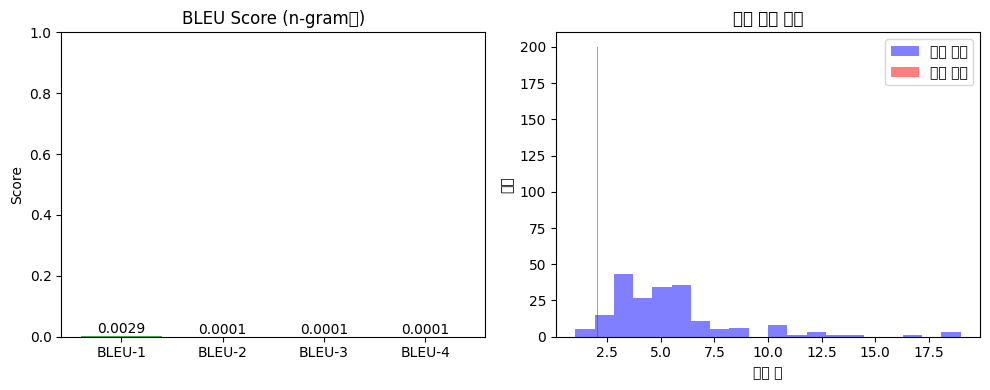


=== 최종 성능 요약 ===
BLEU-1: 0.0029
BLEU-2: 0.0001
BLEU-3: 0.0001
BLEU-4: 0.0001
BLEU 전체: 0.0002
평가 샘플 수: 200개


In [144]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'  # 한글 폰트
import numpy as np
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# BLEU Score 계산
def calculate_bleu_score(questions, answers, n=200):
    references = []
    hypotheses = []

    for q, a in zip(questions[:n], answers[:n]):
        pred        = translate(q)
        pred_tokens = pred.split()
        ref_tokens  = okt.morphs(preprocess_sentence(a))
        references.append([ref_tokens])
        hypotheses.append(pred_tokens)

    smoother = SmoothingFunction().method1
    score    = corpus_bleu(references, hypotheses,
                           smoothing_function=smoother)
    return score, references, hypotheses

print("BLEU Score 계산 중...")
bleu_score, references, hypotheses = calculate_bleu_score(
    list(questions), list(answers), n=200
)
print(f"BLEU Score: {bleu_score:.4f}")

# 샘플 대화 출력
print("\n=== 샘플 대화 10개 ===")
for i in range(10):
    q   = list(questions)[i]
    a   = list(answers)[i]
    pred = translate(q)
    print(f"질문: {q}")
    print(f"정답: {a}")
    print(f"챗봇: {pred}")
    print()

# Loss 그래프 (학습 과정 시각화)
# 학습 루프에서 loss 기록했다면
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)

# BLEU Score 시각화
categories = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
scores = []
smoother = SmoothingFunction().method1
for w in [[1,0,0,0], [0,1,0,0], [0,0,1,0], [0,0,0,1]]:
    s = corpus_bleu(references, hypotheses,
                    weights=w,
                    smoothing_function=smoother)
    scores.append(s)

plt.bar(categories, scores, color=['#4CAF50','#2196F3','#FF9800','#F44336'])
plt.title('BLEU Score (n-gram별)')
plt.ylabel('Score')
plt.ylim(0, 1)
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')

# 답변 길이 분포
plt.subplot(1, 2, 2)
pred_lengths = [len(h) for h in hypotheses]
ref_lengths  = [len(r[0]) for r in references]

plt.hist(ref_lengths,  bins=20, alpha=0.5, label='정답 길이', color='blue')
plt.hist(pred_lengths, bins=20, alpha=0.5, label='챗봇 길이', color='red')
plt.title('답변 길이 분포')
plt.xlabel('단어 수')
plt.ylabel('빈도')
plt.legend()

plt.tight_layout()
plt.show()

# 최종 성능 요약
print("\n=== 최종 성능 요약 ===")
print(f"BLEU-1: {scores[0]:.4f}")
print(f"BLEU-2: {scores[1]:.4f}")
print(f"BLEU-3: {scores[2]:.4f}")
print(f"BLEU-4: {scores[3]:.4f}")
print(f"BLEU 전체: {bleu_score:.4f}")
print(f"평가 샘플 수: 200개")